In [1]:
# !pip install -q "transformers>=4.44" "datasets>=2.18" accelerate scikit-learn matplotlib seaborn
# (Optional) for LoRA section later:
# !pip install -q peft

import os, random, numpy as np, pandas as pd
import warnings

warnings.filterwarnings("ignore")

# === Your proxy & env setup ===
os.environ.setdefault("TOKENIZERS_PARALLELISM", "true")
os.environ["https_proxy"] = "http://10.101.159.162:7890"
os.environ["http_proxy"] = "http://10.101.159.162:7890"

import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [2]:
import os

# === Your paths ===
DATA_DIR = "../data"
RED_WINE_PATH = os.path.join(DATA_DIR, "WineQuality-RedWine.csv")  # red wine quality

# === Task selection (we focus on binary for the red wine dataset) ===
TASK = "red_quality_binary"  # good (>=7) vs not_good
GOOD_THRESHOLD = 7

# === Prompt & model settings ===
MODEL_NAME = "gpt2"  # try "distilgpt2" if you need lower memory
MAX_LENGTH = 256
BATCH_TRAIN = 16
BATCH_EVAL = 32
EPOCHS = 5
LR = 5e-5
WEIGHT_DECAY = 0.01

# Ablation settings
TEMPLATES = ["bullet", "inline"]  # serialization styles
TOPK_LIST = [None, 5, 7]  # None = all features; else FS top-k

# Output dirs
RUN_ROOT = "runs/gpt2_prompt_tabular"
OUT_DIR = os.path.join(RUN_ROOT, "ablation")
os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
import pandas as pd

df = pd.read_csv(RED_WINE_PATH)
assert "quality" in df.columns, "Expected 'quality' in WineQuality-RedWine.csv"

# Binary label
df["label"] = (df["quality"] >= GOOD_THRESHOLD).astype(int)  # 1=good
feature_cols = [c for c in df.columns if c not in ["quality", "label"]]

id2label = {0: "not_good", 1: "good"}
label2id = {"not_good": 0, "good": 1}

print("Rows:", len(df))
print("Features:", feature_cols)
df.head(3)

Rows: 1599
Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0


In [4]:
def serialize_row(row, cols, template="bullet"):
    # Optional pretty names/units for UCI red wine features
    pretty = {
        "fixed acidity": ("fixed acidity", "g/dm^3"),
        "volatile acidity": ("volatile acidity", "g/dm^3"),
        "citric acid": ("citric acid", "g/dm^3"),
        "residual sugar": ("residual sugar", "g/dm^3"),
        "chlorides": ("chlorides", "g/dm^3"),
        "free sulfur dioxide": ("free sulfur dioxide", "mg/dm^3"),
        "total sulfur dioxide": ("total sulfur dioxide", "mg/dm^3"),
        "density": ("density", "g/cm^3"),
        "pH": ("pH", ""),
        "sulphates": ("sulphates", "g/dm^3"),
        "alcohol": ("alcohol", "% vol"),
    }

    def nm(c):
        return pretty.get(c, (c, ""))[0]

    def unit(c):
        return pretty.get(c, (c, ""))[1]

    if template == "bullet":
        lines = ["The following red wine has these lab measurements:"]
        for c in cols:
            u = unit(c)
            v = row[c]
            lines.append(f"- {nm(c)}: {v} {u}".rstrip())
        lines += [
            "",
            "Question: Is this wine high quality (good) or not good?",
            "Answer:",
        ]
        return "\n".join(lines)
    else:  # inline
        parts = []
        for c in cols:
            u = unit(c)
            v = row[c]
            parts.append(f"{nm(c)} {v}{(' ' + u) if u else ''}".strip())
        body = ", ".join(parts[:-1]) + (", and " + parts[-1] if parts else "")
        return f"Given a red wine with {body}. Is this wine high quality (good) or not good? Answer:"

In [5]:
from sklearn.model_selection import train_test_split

df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

X_train, X_test = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df["label"]
)
X_train, X_val = train_test_split(
    X_train, test_size=0.2, random_state=SEED, stratify=X_train["label"]
)

for name, split in [("train", X_train), ("val", X_val), ("test", X_test)]:
    print(
        name,
        split.shape,
        split["label"].value_counts(normalize=True).round(3).to_dict(),
    )

train (1023, 13) {0: 0.864, 1: 0.136}
val (256, 13) {0: 0.863, 1: 0.137}
test (320, 13) {0: 0.866, 1: 0.134}


In [6]:
from sklearn.feature_selection import mutual_info_classif


def select_topk_features(X_df, y_series, all_features, top_k=None):
    if (top_k is None) or (top_k >= len(all_features)):
        return list(all_features)
    X = X_df[all_features].values
    mi = mutual_info_classif(X, y_series, random_state=SEED)
    order = np.argsort(mi)[::-1]
    selected = [all_features[i] for i in order[:top_k]]
    return selected


# Precompute once for convenience
fs_cache = {}
for k in [k for k in TOPK_LIST if k is not None]:
    fs_cache[k] = select_topk_features(X_train, X_train["label"], feature_cols, k)

fs_cache  # shows the selected features per k

{5: ['alcohol',
  'sulphates',
  'volatile acidity',
  'fixed acidity',
  'citric acid'],
 7: ['alcohol',
  'sulphates',
  'volatile acidity',
  'fixed acidity',
  'citric acid',
  'density',
  'chlorides']}

In [7]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


def build_text_column(df_in, cols, template):
    return df_in.apply(lambda r: serialize_row(r, cols, template), axis=1)


def to_hf(split_df):
    return Dataset.from_pandas(split_df[["text", "label"]].reset_index(drop=True))


def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)


def make_tokenized_ds(train_df, val_df, test_df):
    raw = DatasetDict(
        {
            "train": to_hf(train_df),
            "validation": to_hf(val_df),
            "test": to_hf(test_df),
        }
    )
    tok = raw.map(tokenize_fn, batched=True, remove_columns=["text"])
    return tok

In [8]:
from transformers import GPT2ForSequenceClassification, TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score, classification_report

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


def run_one(seed, template, top_k=None, epochs=EPOCHS, lr=LR):
    # choose feature subset
    if top_k is None:
        use_cols = list(feature_cols)
    else:
        # use cached MI features computed on training data
        use_cols = fs_cache[top_k]

    # build prompts
    tr = X_train.copy()
    va = X_val.copy()
    te = X_test.copy()
    tr["text"] = build_text_column(tr, use_cols, template)
    va["text"] = build_text_column(va, use_cols, template)
    te["text"] = build_text_column(te, use_cols, template)

    # tokenize
    tok_ds = make_tokenized_ds(tr, va, te)

    # model
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    model = GPT2ForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        pad_token_id=tokenizer.pad_token_id,
        id2label=id2label,
        label2id=label2id,
    ).to(DEVICE)

    # metrics
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = logits.argmax(-1)
        return {
            "accuracy": float(accuracy_score(labels, preds)),
            "f1_macro": float(f1_score(labels, preds, average="macro")),
        }

    # training args
    out_dir = os.path.join(
        OUT_DIR, f"seed{seed}_{template}_topk{top_k if top_k is not None else 'all'}"
    )
    args = TrainingArguments(
        output_dir=out_dir,
        logging_dir=os.path.join(out_dir, "logs"),
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=BATCH_TRAIN,
        per_device_eval_batch_size=BATCH_EVAL,
        learning_rate=lr,
        num_train_epochs=epochs,
        weight_decay=WEIGHT_DECAY,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=2,
        report_to="none",
        seed=seed,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tok_ds["train"],
        eval_dataset=tok_ds["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    # test evaluation
    test_pred = trainer.predict(tok_ds["test"])
    y_true = test_pred.label_ids
    y_pred = test_pred.predictions.argmax(-1)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")

    # save a small report
    rep = classification_report(
        y_true, y_pred, target_names=["not_good", "good"], output_dict=True
    )
    rep_df = pd.DataFrame(rep).T
    rep_df.to_csv(os.path.join(out_dir, "test_classification_report.csv"))

    return {
        "seed": seed,
        "template": template,
        "top_k": (top_k if top_k is not None else len(feature_cols)),
        "features_used": use_cols,
        "test_accuracy": acc,
        "test_f1_macro": f1,
        "run_dir": out_dir,
    }

In [9]:
SEEDS = [42, 43]  # increase to [42,43,44,45,46] when you want stronger statistics

all_rows = []
for s in SEEDS:
    for tmpl in TEMPLATES:
        for top_k in TOPK_LIST:
            # ensure fs_cache has this k if not None
            if (top_k is not None) and (top_k not in fs_cache):
                fs_cache[top_k] = select_topk_features(
                    X_train, X_train["label"], feature_cols, top_k
                )
            row = run_one(seed=s, template=tmpl, top_k=top_k)
            all_rows.append(row)
            print(
                f"Done: seed={s}, template={tmpl}, top_k={top_k} -> F1={row['test_f1_macro']:.4f}"
            )

results_df = pd.DataFrame(all_rows)
results_path = os.path.join(OUT_DIR, "ablation_results.csv")
results_df.to_csv(results_path, index=False)
results_df.sort_values("test_f1_macro", ascending=False).head(10)

Map:   0%|          | 0/1023 [00:00<?, ? examples/s]

Map:   0%|          | 0/256 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/320 [00:00<?, ?it/s]

...

  0%|          | 0/8 [00:00<?, ?it/s]

{'eval_loss': 0.3383108377456665, 'eval_accuracy': 0.86328125, 'eval_f1_macro': 0.46331236897274636, 'eval_runtime': 5.5517, 'eval_samples_per_second': 46.112, 'eval_steps_per_second': 1.441, 'epoch': 5.0}
{'train_runtime': 271.0708, 'train_samples_per_second': 18.87, 'train_steps_per_second': 1.181, 'train_loss': 0.3956906318664551, 'epoch': 5.0}


  0%|          | 0/10 [00:00<?, ?it/s]

Done: seed=43, template=inline, top_k=7 -> F1=0.4640


,seed,template,top_k,features_used,test_accuracy,test_f1_macro,run_dir
5,42,inline,7,"[alcohol, sulphates, volatile acidity, fixed a...",0.878125,0.691081,runs/gpt2_prompt_tabular\ablation\seed42_inlin...
2,42,bullet,7,"[alcohol, sulphates, volatile acidity, fixed a...",0.875000,0.670917,runs/gpt2_prompt_tabular\ablation\seed42_bulle...
3,42,inline,11,"[fixed acidity, volatile acidity, citric acid,...",0.878125,0.584540,runs/gpt2_prompt_tabular\ablation\seed42_inlin...
0,42,bullet,11,"[fixed acidity, volatile acidity, citric acid,...",0.865625,0.463987,runs/gpt2_prompt_tabular\ablation\seed42_bulle...
1,42,bullet,5,"[alcohol, sulphates, volatile acidity, fixed a...",0.865625,0.463987,runs/gpt2_prompt_tabular\ablation\seed42_bulle...
4,42,inline,5,"[alcohol, sulphates, volatile acidity, fixed a...",0.865625,0.463987,runs/gpt2_prompt_tabular\ablation\seed42_inlin...
6,43,bullet,11,"[fixed acidity, volatile acidity, citric acid,...",0.865625,0.463987,runs/gpt2_prompt_tabular\ablation\seed43_bulle...
7,43,bullet,5,"[alcohol, sulphates, volatile acidity, fixed a...",0.865625,0.463987,runs/gpt2_prompt_tabular\ablation\seed43_bulle...
8,43,bullet,7,"[alcohol, sulphates, volatile acidity, fixed a...",0.865625,0.463987,runs/gpt2_prompt_tabular\ablation\seed43_bulle...
9,43,inline,11,"[fixed acidity, volatile acidity, citric acid,...",0.865625,0.463987,runs/gpt2_prompt_tabular\ablation\seed43_inlin...


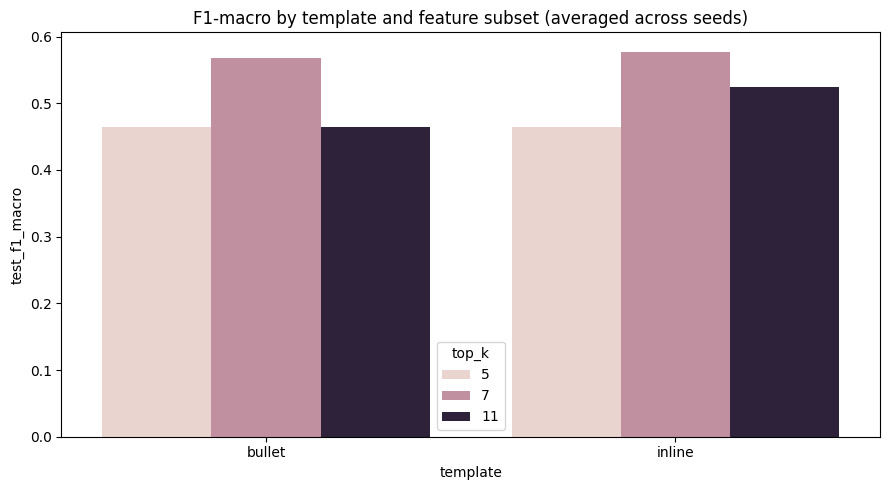

seed                                                            42
template                                                    inline
top_k                                                            7
features_used    [alcohol, sulphates, volatile acidity, fixed a...
test_accuracy                                             0.878125
test_f1_macro                                             0.691081
run_dir          runs/gpt2_prompt_tabular\ablation\seed42_inlin...
Name: 5, dtype: object

In [10]:
import seaborn as sns, matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
sns.barplot(
    data=results_df, x="template", y="test_f1_macro", hue="top_k", errorbar=None
)
plt.title("F1-macro by template and feature subset (averaged across seeds)")
plt.tight_layout()
plt.show()

best = results_df.sort_values("test_f1_macro", ascending=False).iloc[0]
best

In [11]:
# OPTIONAL: LoRA (parameter-efficient tuning)
try:
    from peft import LoraConfig, get_peft_model
    from transformers import GPT2ForSequenceClassification, TrainingArguments, Trainer

    use_lora = True
except Exception as e:
    print("PEFT not installed. Run: pip install peft")
    use_lora = False

if use_lora:
    seed = int(best["seed"])
    template = best["template"]
    top_k = int(best["top_k"])
    use_cols = fs_cache[top_k] if top_k != len(feature_cols) else list(feature_cols)

    tr = X_train.copy()
    va = X_val.copy()
    te = X_test.copy()
    tr["text"] = build_text_column(tr, use_cols, template)
    va["text"] = build_text_column(va, use_cols, template)
    te["text"] = build_text_column(te, use_cols, template)

    tok_ds = make_tokenized_ds(tr, va, te)

    base = GPT2ForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        pad_token_id=tokenizer.pad_token_id,
        id2label=id2label,
        label2id=label2id,
    ).to(DEVICE)

    lora_cfg = LoraConfig(
        r=8,
        lora_alpha=16,
        lora_dropout=0.05,
        bias="none",
        task_type="SEQ_CLS",
        target_modules=["c_attn", "c_proj"],  # GPT-2 attention/projection modules
    )
    lora_model = get_peft_model(base, lora_cfg)
    lora_model.print_trainable_parameters()

    out_dir = os.path.join(OUT_DIR, f"lora_seed{seed}_{template}_topk{top_k}")
    args = TrainingArguments(
        output_dir=out_dir,
        logging_dir=os.path.join(out_dir, "logs"),
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=BATCH_TRAIN,
        per_device_eval_batch_size=BATCH_EVAL,
        learning_rate=LR,
        num_train_epochs=EPOCHS,
        weight_decay=WEIGHT_DECAY,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=2,
        report_to="none",
        seed=seed,
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = logits.argmax(-1)
        return {
            "accuracy": float(accuracy_score(labels, preds)),
            "f1_macro": float(f1_score(labels, preds, average="macro")),
        }

    trainer = Trainer(
        model=lora_model,
        args=args,
        train_dataset=tok_ds["train"],
        eval_dataset=tok_ds["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainer.train()

    test_pred = trainer.predict(tok_ds["test"])
    y_true = test_pred.label_ids
    y_pred = test_pred.predictions.argmax(-1)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    print(f"LoRA test F1: {f1:.4f}, Acc: {acc:.4f}")

Map:   0%|          | 0/1023 [00:00<?, ? examples/s]

Map:   0%|          | 0/256 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 812,544 || all params: 125,253,888 || trainable%: 0.6487


...

{'eval_loss': 0.4078938961029053, 'eval_accuracy': 0.86328125, 'eval_f1_macro': 0.46331236897274636, 'eval_runtime': 2.3827, 'eval_samples_per_second': 107.439, 'eval_steps_per_second': 3.357, 'epoch': 4.0}


  0%|          | 0/8 [00:00<?, ?it/s]

{'eval_loss': 0.4107663631439209, 'eval_accuracy': 0.86328125, 'eval_f1_macro': 0.46331236897274636, 'eval_runtime': 2.3275, 'eval_samples_per_second': 109.989, 'eval_steps_per_second': 3.437, 'epoch': 5.0}
{'train_runtime': 138.8458, 'train_samples_per_second': 36.839, 'train_steps_per_second': 2.305, 'train_loss': 0.6866651058197022, 'epoch': 5.0}


  0%|          | 0/10 [00:00<?, ?it/s]

LoRA test F1: 0.4640, Acc: 0.8656
